# POS Tagging with Unidirectional LSTM and BiLSTM

This notebook builds a complete **token-level Part-of-Speech tagging pipeline** for the Kaggle dataset [NER Dataset with POS Tags](https://www.kaggle.com/datasets/rohitr4307/ner-dataset).

Although the source dataset also contains Named Entity Recognition labels, this notebook uses **only POS tags as prediction targets**. A unidirectional LSTM and a bidirectional LSTM are trained on the same sentence-level splits and compared fairly.


## 1. Install and Import Libraries

`kagglehub` is used for anonymous download of the public dataset in Google Colab. The remaining packages are normally available in a standard Colab runtime.


In [1]:
!pip -q install -U kagglehub seaborn


In [2]:
import ast
import json
import os
import random
import re
import unicodedata
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


## 2. Configuration

Both models use the same embedding size, hidden size, optimizer settings, split, and epoch limit. `EPOCHS` is capped at 10.


In [3]:
SEED = 42
DATASET_SLUG = "rohitr4307/ner-dataset"

BASE_DIR = Path("/content/pos_tagging_bilstm")
DOWNLOAD_DIR = BASE_DIR / "download"
EXTRACT_DIR = BASE_DIR / "data"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"

# Sentence-level split configuration.
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15
# Limit the number of complete sentences for a quick run; use None for all data.
SAMPLE_LIMIT = None

# Vocabulary and sequence configuration.
MAX_WORD_VOCAB_SIZE = 50000
MIN_WORD_FREQUENCY = 1

# Shared model hyperparameters.
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.30

# Shared training hyperparameters.
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 3
# Keep loading in the notebook process to avoid Colab worker crashes.
NUM_WORKERS = 0

assert 1 <= EPOCHS <= 10
assert SAMPLE_LIMIT is None or (isinstance(SAMPLE_LIMIT, int) and SAMPLE_LIMIT > 0)
assert NUM_WORKERS == 0


## 3. Reproducibility and Device

Random generators are fixed and CUDA is selected automatically when a GPU runtime is available.


In [4]:
def set_seed(seed: int = SEED) -> None:
    # Fix Python, NumPy, and PyTorch randomness.
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Prefer deterministic CUDA operations when supported.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        pass


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.13.0+cpu
Using device: cpu


## 4. Download and Extract the Dataset

`kagglehub` downloads and extracts the public dataset without requiring a `kaggle.json` upload. The returned directory is used directly, so the cell also works when Kaggle changes its cache location.


In [5]:
import kagglehub

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
downloaded_dataset_path = kagglehub.dataset_download(DATASET_SLUG)
EXTRACT_DIR = Path(downloaded_dataset_path)

if not EXTRACT_DIR.exists():
    raise FileNotFoundError(f"Kaggle dataset directory was not created: {EXTRACT_DIR}")

all_files = sorted(path for path in EXTRACT_DIR.rglob("*") if path.is_file())

if not all_files:
    raise FileNotFoundError(f"No files were downloaded to {EXTRACT_DIR}")

print(f"Dataset directory: {EXTRACT_DIR}")
print(f"Found {len(all_files)} file(s):")
for path in all_files:
    print(f" - {path.relative_to(EXTRACT_DIR)} ({path.stat().st_size:,} bytes)")


100%|██████████| 4.45M/4.45M [00:07<00:00, 604kB/s]

Extracting files...
Dataset directory: C:\Users\aaa\.cache\kagglehub\datasets\rohitr4307\ner-dataset\versions\1
Found 1 file(s):
 - NER_Dataset.csv (22,910,278 bytes)


## 5. Inspect All Files and Column Names

The loader searches for common tabular formats and tries Unicode-safe encoding and delimiter fallbacks. Every readable table, shape, column list, data type, and preview is printed.


In [6]:
SUPPORTED_SUFFIXES = {".csv", ".tsv", ".txt", ".json", ".jsonl", ".xlsx", ".xls", ".parquet"}


def read_delimited_file(path: Path) -> pd.DataFrame:
    """Read a delimited file using common encodings and separators."""
    separators = ["\t"] if path.suffix.lower() == ".tsv" else [None, ",", "\t", ";", "|"]
    errors = []
    for encoding in ("utf-8-sig", "utf-8", "latin-1", "cp1252"):
        for separator in separators:
            try:
                frame = pd.read_csv(
                    path,
                    sep=separator,
                    engine="python",
                    encoding=encoding,
                    on_bad_lines="skip",
                )
                if frame.shape[1] >= 3 and len(frame) > 0:
                    return frame
            except Exception as exc:
                errors.append(f"{encoding}/{separator}: {exc}")
    raise ValueError(f"Could not parse {path.name}. Last errors: {errors[-3:]}")


def read_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".csv", ".tsv", ".txt"}:
        return read_delimited_file(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    if suffix == ".json":
        try:
            return pd.read_json(path)
        except ValueError:
            return pd.read_json(path, lines=True)
    raise ValueError(f"Unsupported file type: {suffix}")


tabular_files = [path for path in all_files if path.suffix.lower() in SUPPORTED_SUFFIXES]
if not tabular_files:
    raise FileNotFoundError("No supported tabular files were found.")

loaded_tables = {}
for path in tabular_files:
    try:
        frame = read_table(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        loaded_tables[path] = frame
        print("\n" + "=" * 100)
        print(f"FILE: {path.relative_to(EXTRACT_DIR)} | shape={frame.shape}")
        print("COLUMNS:", list(frame.columns))
        display(frame.head(5))
        print(frame.dtypes.to_string())
    except Exception as exc:
        print(f"Skipped {path.relative_to(EXTRACT_DIR)}: {exc}")

if not loaded_tables:
    raise RuntimeError("Files were found, but none could be parsed as a table.")



FILE: NER_Dataset.csv | shape=(47959, 4)
COLUMNS: ['Sentence_ID', 'Word', 'POS', 'Tag']


,Sentence_ID,Word,POS,Tag
0,Sentence: 1,"['Thousands', 'of', 'demonstrators', 'have', '...","['NNS', 'IN', 'NNS', 'VBP', 'VBN', 'IN', 'NNP'...","['O', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', '..."
1,Sentence: 10,"['Iranian', 'officials', 'say', 'they', 'expec...","['JJ', 'NNS', 'VBP', 'PRP', 'VBP', 'TO', 'VB',...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '..."
2,Sentence: 100,"['Helicopter', 'gunships', 'Saturday', 'pounde...","['NN', 'NNS', 'NNP', 'VBD', 'JJ', 'NNS', 'IN',...","['O', 'O', 'B-tim', 'O', 'O', 'O', 'O', 'O', '..."
3,Sentence: 1000,"['They', 'left', 'after', 'a', 'tense', 'hour-...","['PRP', 'VBD', 'IN', 'DT', 'NN', 'JJ', 'NN', '...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
4,Sentence: 10000,"['U.N.', 'relief', 'coordinator', 'Jan', 'Egel...","['NNP', 'NN', 'NN', 'NNP', 'NNP', 'VBD', 'NNP'...","['B-geo', 'O', 'O', 'B-per', 'I-per', 'O', 'B-..."


Sentence_ID    object
Word           object
POS            object
Tag            object


## 6. Automatically Detect Sentence ID, Token, and POS Columns

Detection combines normalized column-name hints with data characteristics. The known source schema (`Sentence #`, `Word`, `POS`, `Tag`) is supported, but no fixed column name is required.

The NER column may be inspected with the other columns, but it is deliberately excluded from target detection and model inputs.


In [7]:
SENTENCE_HINTS = (
    "sentence_id", "sentence_number", "sentence_no", "sentence", "sent_id",
    "sentencenum", "sent", "group", "sequence_id",
)
TOKEN_HINTS = ("word", "token", "tokens", "term", "surface", "text")
POS_HINTS = (
    "pos", "pos_tag", "postag", "part_of_speech", "partofspeech",
    "word_type", "grammatical_tag",
)
NER_HINTS = ("ner", "named_entity", "entity", "iob", "bio")


def normalized_column_name(name: str) -> str:
    """Normalize column names for hint matching without changing data values."""
    value = unicodedata.normalize("NFKD", str(name).lower())
    value = "".join(character for character in value if not unicodedata.combining(character))
    return re.sub(r"[^a-z0-9]+", "_", value).strip("_")


def contains_hint(name: str, hints: tuple[str, ...]) -> bool:
    normalized = normalized_column_name(name)
    return any(hint == normalized or hint in normalized for hint in hints)


def sentence_id_score(series: pd.Series, name: str) -> float:
    non_missing = series.dropna()
    if non_missing.empty:
        return float("-inf")
    name_score = 15.0 if contains_hint(name, SENTENCE_HINTS) else 0.0
    missing_bonus = 4.0 if series.isna().mean() > 0 else 0.0
    repeated_ratio = 1.0 - non_missing.astype(str).nunique() / max(1, len(non_missing))
    return name_score + missing_bonus + 5.0 * repeated_ratio


def token_score(series: pd.Series, name: str) -> float:
    values = series.dropna().astype(str)
    if values.empty:
        return float("-inf")
    sample = values.head(5000)
    name_score = 15.0 if contains_hint(name, TOKEN_HINTS) else 0.0
    short_value_bonus = 4.0 if sample.str.len().median() <= 20 else 0.0
    unique_ratio = sample.nunique() / max(1, len(sample))
    return name_score + short_value_bonus + unique_ratio


def parse_list_value(value):
    """Parse a Python/JSON-style list stored in a CSV cell when present."""
    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)
    if isinstance(value, str) and value.strip().startswith("["):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple)):
                return list(parsed)
        except (ValueError, SyntaxError):
            pass
    return None


def pos_score(series: pd.Series, name: str) -> float:
    raw_values = series.dropna()
    values = raw_values.astype(str)
    if values.empty:
        return float("-inf")

    # Some Kaggle versions store one complete POS list per CSV row.
    parsed_samples = [parse_list_value(value) for value in raw_values.head(1000)]
    parsed_tags = [
        str(tag)
        for sequence in parsed_samples
        if sequence is not None
        for tag in sequence
    ]
    unique_count = len(set(parsed_tags)) if parsed_tags else values.nunique()
    if unique_count < 2 or unique_count > 500:
        return float("-inf")
    name_score = 20.0 if contains_hint(name, POS_HINTS) else 0.0
    ner_penalty = 25.0 if contains_hint(name, NER_HINTS) else 0.0
    short_tag_bonus = 5.0 if values.head(5000).str.len().median() <= 10 else 0.0
    cardinality_bonus = 5.0 if unique_count <= 100 else 0.0
    return name_score + short_tag_bonus + cardinality_bonus - ner_penalty


def detect_sequence_schema(tables: dict) -> tuple:
    candidates = []
    for path, frame in tables.items():
        columns = list(frame.columns)
        for sentence_column in columns:
            for token_column in columns:
                for pos_column in columns:
                    if len({sentence_column, token_column, pos_column}) < 3:
                        continue
                    score = (
                        sentence_id_score(frame[sentence_column], sentence_column)
                        + token_score(frame[token_column], token_column)
                        + pos_score(frame[pos_column], pos_column)
                        + min(np.log10(len(frame) + 1), 6.0)
                    )
                    candidates.append((score, path, sentence_column, token_column, pos_column))
    valid_candidates = [candidate for candidate in candidates if np.isfinite(candidate[0])]
    if not valid_candidates:
        raise ValueError("Could not detect sentence ID, token, and POS columns.")
    return max(valid_candidates, key=lambda candidate: candidate[0])


schema_score, selected_path, sentence_id_column, token_column, pos_column = detect_sequence_schema(
    loaded_tables
)
raw_df = loaded_tables[selected_path].copy()

print(f"Selected file: {selected_path.relative_to(EXTRACT_DIR)}")
print(f"Detected sentence ID column: {sentence_id_column!r}")
print(f"Detected token column: {token_column!r}")
print(f"Detected POS column: {pos_column!r}")
print(f"Detection score: {schema_score:.3f}")

possible_ner_columns = [
    column for column in raw_df.columns if contains_hint(column, NER_HINTS)
]
print(f"Possible NER columns (not used): {possible_ner_columns}")


Selected file: NER_Dataset.csv
Detected sentence ID column: 'Sentence_ID'
Detected token column: 'Word'
Detected POS column: 'POS'
Detection score: 60.680
Possible NER columns (not used): []


## 7. Forward-Fill Sentence IDs and Clean Token/POS Rows

In this dataset, a sentence identifier can appear only on the first token row. Forward filling restores the identifier for every subsequent token. Rows missing a token or POS tag are removed; NER labels are never selected.


In [8]:
selected_df = raw_df[[sentence_id_column, token_column, pos_column]].copy()
selected_df.columns = ["sentence_id", "token", "pos"]
selected_df["sentence_id"] = selected_df["sentence_id"].ffill()

# Support both common layouts:
# 1) one token per row, with sentence IDs forward-filled; and
# 2) one sentence per row, with Word/POS stored as serialized Python lists.
sequence_records = []
for row in selected_df.itertuples(index=False):
    if pd.isna(row.sentence_id) or pd.isna(row.token) or pd.isna(row.pos):
        continue

    sentence_id = str(row.sentence_id).strip()
    token_sequence = parse_list_value(row.token)
    pos_sequence = parse_list_value(row.pos)

    if token_sequence is not None or pos_sequence is not None:
        if token_sequence is None or pos_sequence is None:
            raise ValueError(
                f"Sentence {sentence_id!r} has a list in only one of Word/POS columns."
            )
        if len(token_sequence) != len(pos_sequence):
            raise ValueError(
                f"Sentence {sentence_id!r} has {len(token_sequence)} tokens but "
                f"{len(pos_sequence)} POS tags."
            )
        sequence_records.extend(
            {
                "sentence_id": sentence_id,
                "token": token,
                "pos": pos,
            }
            for token, pos in zip(token_sequence, pos_sequence)
        )
    else:
        sequence_records.append(
            {
                "sentence_id": sentence_id,
                "token": row.token,
                "pos": row.pos,
            }
        )

sequence_df = pd.DataFrame(sequence_records, columns=["sentence_id", "token", "pos"])
if sequence_df.empty:
    raise ValueError("No aligned token/POS rows could be parsed from the selected table.")

# Keep text values intact apart from Unicode normalization and surrounding spaces.
for column in ("sentence_id", "token", "pos"):
    sequence_df[column] = sequence_df[column].astype(str).map(
        lambda value: unicodedata.normalize("NFC", value).strip()
    )
sequence_df = sequence_df[
    (sequence_df["sentence_id"] != "")
    & (sequence_df["token"] != "")
    & (sequence_df["pos"] != "")
].reset_index(drop=True)

print(f"Usable token rows: {len(sequence_df):,}")
print(f"Complete sentence IDs: {sequence_df['sentence_id'].nunique():,}")
print(f"Distinct POS tags: {sequence_df['pos'].nunique():,}")
display(sequence_df.head(12))
display(sequence_df["pos"].value_counts().to_frame("token_count"))


Usable token rows: 1,048,571
Complete sentence IDs: 47,959
Distinct POS tags: 42


,sentence_id,token,pos
0,Sentence: 1,Thousands,NNS
1,Sentence: 1,of,IN
2,Sentence: 1,demonstrators,NNS
3,Sentence: 1,have,VBP
4,Sentence: 1,marched,VBN
5,Sentence: 1,through,IN
6,Sentence: 1,London,NNP
7,Sentence: 1,to,TO
8,Sentence: 1,protest,VB
9,Sentence: 1,the,DT


,token_count
pos,
NN,145807
NNP,131426
IN,120996
DT,98454
JJ,78412
NNS,75840
.,47831
VBD,39379
",",32754


## 8. Group Complete Sentence-Level Sequences

Rows are grouped in original order. Each example contains a full token sequence and its exactly aligned POS-tag sequence.


In [9]:
sentences_df = (
    sequence_df.groupby("sentence_id", sort=False)
    .agg(tokens=("token", list), pos_tags=("pos", list))
    .reset_index()
)

valid_alignment = sentences_df.apply(
    lambda row: len(row["tokens"]) == len(row["pos_tags"]) and len(row["tokens"]) > 0,
    axis=1,
)
sentences_df = sentences_df[valid_alignment].reset_index(drop=True)

if sentences_df.empty:
    raise ValueError("No aligned sentence-level sequences were created.")

# Apply the optional limit only after grouping, so a sentence is never truncated.
if SAMPLE_LIMIT is not None and SAMPLE_LIMIT < len(sentences_df):
    if SAMPLE_LIMIT < 3:
        raise ValueError("SAMPLE_LIMIT must be at least 3 complete sentences.")
    sentences_df = sentences_df.sample(
        n=SAMPLE_LIMIT,
        random_state=SEED,
    ).reset_index(drop=True)
    print(f"SAMPLE_LIMIT active: using {len(sentences_df):,} complete sentences.")
elif SAMPLE_LIMIT is not None:
    print(
        f"SAMPLE_LIMIT={SAMPLE_LIMIT:,} is not below the dataset size; using all sentences."
    )

sentence_lengths = sentences_df["tokens"].map(len)
print(f"Number of sentences: {len(sentences_df):,}")
print(sentence_lengths.describe().to_string())
for index in range(min(3, len(sentences_df))):
    print("\nSentence ID:", sentences_df.loc[index, "sentence_id"])
    print("Tokens:", sentences_df.loc[index, "tokens"])
    print("POS tags:", sentences_df.loc[index, "pos_tags"])


Number of sentences: 47,959
count    47959.000000
mean        21.863905
std          7.963458
min          1.000000
25%         16.000000
50%         21.000000
75%         27.000000
max        104.000000

Sentence ID: Sentence: 1
Tokens: ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the', 'war', 'in', 'Iraq', 'and', 'demand', 'the', 'withdrawal', 'of', 'British', 'troops', 'from', 'that', 'country', '.']
POS tags: ['NNS', 'IN', 'NNS', 'VBP', 'VBN', 'IN', 'NNP', 'TO', 'VB', 'DT', 'NN', 'IN', 'NNP', 'CC', 'VB', 'DT', 'NN', 'IN', 'JJ', 'NNS', 'IN', 'DT', 'NN', '.']

Sentence ID: Sentence: 10
Tokens: ['Iranian', 'officials', 'say', 'they', 'expect', 'to', 'get', 'access', 'to', 'sealed', 'sensitive', 'parts', 'of', 'the', 'plant', 'Wednesday', ',', 'after', 'an', 'IAEA', 'surveillance', 'system', 'begins', 'functioning', '.']
POS tags: ['JJ', 'NNS', 'VBP', 'PRP', 'VBP', 'TO', 'VB', 'NN', 'TO', 'JJ', 'JJ', 'NNS', 'IN', 'DT', 'NN', 'NNP', ',',

## 9. Split by Complete Sentences

Splitting occurs only after grouping, so tokens from one sentence can never leak across train, validation, and test sets. The two models reuse these exact DataFrames.


In [10]:
train_val_df, test_df = train_test_split(
    sentences_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)
relative_validation_size = VALIDATION_SIZE / (1.0 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_validation_size,
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_ids = set(train_df["sentence_id"])
val_ids = set(val_df["sentence_id"])
test_ids = set(test_df["sentence_id"])
assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print(f"Train sentences: {len(train_df):,} ({len(train_df) / len(sentences_df):.1%})")
print(f"Validation sentences: {len(val_df):,} ({len(val_df) / len(sentences_df):.1%})")
print(f"Test sentences: {len(test_df):,} ({len(test_df) / len(sentences_df):.1%})")


Train sentences: 33,571 (70.0%)
Validation sentences: 7,194 (15.0%)
Test sentences: 7,194 (15.0%)


## 10. Build Word and POS Vocabularies from Training Data Only

The word vocabulary contains `<PAD>` and `<UNK>` and is built only from training text. POS tags form the task's fixed output schema, so their ID mapping is built from the selected sentence corpus; this keeps rare validation/test tags valid when `SAMPLE_LIMIT` is active.


In [11]:
word_counter = Counter(
    token
    for tokens in train_df["tokens"]
    for token in tokens
)
# POS is a fixed output schema, so build its ID mapping from the selected corpus.
# This prevents validation/test KeyError when SAMPLE_LIMIT produces a rare tag
# that is absent from the training subset. The word vocabulary remains train-only.
corpus_pos_tags = sorted(
    {
        tag
        for tags in sentences_df["pos_tags"]
        for tag in tags
    }
)

word_special_tokens = ["<PAD>", "<UNK>"]
word_tokens = [
    word
    for word, frequency in word_counter.most_common()
    if frequency >= MIN_WORD_FREQUENCY
][: MAX_WORD_VOCAB_SIZE - len(word_special_tokens)]

id_to_word = word_special_tokens + word_tokens
word_to_id = {word: index for index, word in enumerate(id_to_word)}
WORD_PAD_ID = word_to_id["<PAD>"]
WORD_UNK_ID = word_to_id["<UNK>"]

id_to_pos = ["<PAD>"] + corpus_pos_tags
pos_to_id = {tag: index for index, tag in enumerate(id_to_pos)}
POS_PAD_ID = pos_to_id["<PAD>"]
WORD_VOCAB_SIZE = len(id_to_word)
NUM_POS_CLASSES = len(id_to_pos)
print(f"Word vocabulary size: {WORD_VOCAB_SIZE:,}")
print(f"POS vocabulary size (including <PAD>): {NUM_POS_CLASSES:,}")
print(f"WORD_PAD_ID={WORD_PAD_ID}, WORD_UNK_ID={WORD_UNK_ID}, POS_PAD_ID={POS_PAD_ID}")
print("POS mapping:", pos_to_id)


Word vocabulary size: 30,157
POS vocabulary size (including <PAD>): 43
WORD_PAD_ID=0, WORD_UNK_ID=1, POS_PAD_ID=0
POS mapping: {'<PAD>': 0, '$': 1, ',': 2, '.': 3, ':': 4, ';': 5, 'CC': 6, 'CD': 7, 'DT': 8, 'EX': 9, 'FW': 10, 'IN': 11, 'JJ': 12, 'JJR': 13, 'JJS': 14, 'LRB': 15, 'MD': 16, 'NN': 17, 'NNP': 18, 'NNPS': 19, 'NNS': 20, 'PDT': 21, 'POS': 22, 'PRP': 23, 'PRP$': 24, 'RB': 25, 'RBR': 26, 'RBS': 27, 'RP': 28, 'RRB': 29, 'TO': 30, 'UH': 31, 'VB': 32, 'VBD': 33, 'VBG': 34, 'VBN': 35, 'VBP': 36, 'VBZ': 37, 'WDT': 38, 'WP': 39, 'WP$': 40, 'WRB': 41, '``': 42}


## 11. Dataset and Simultaneous Dynamic Padding

The collate function pads word IDs and POS IDs to the longest sentence in each batch. It also returns true lengths, allowing packed recurrent computation. Word and target tensors always have identical shapes.


In [13]:
class POSTaggingDataset(Dataset):
    """Sentence-level word and POS sequences."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> dict:
        tokens = self.frame.loc[index, "tokens"]
        pos_tags = self.frame.loc[index, "pos_tags"]
        word_ids = [word_to_id.get(token, WORD_UNK_ID) for token in tokens]
        pos_ids = [pos_to_id[tag] for tag in pos_tags]
        assert len(word_ids) == len(pos_ids)
        return {
            "word_ids": word_ids,
            "pos_ids": pos_ids,
            "length": len(word_ids),
            "index": index,
        }


def pad_batch(examples: list[dict]) -> dict[str, torch.Tensor]:
    """Pad word and POS sequences together to the batch maximum length."""
    batch_size = len(examples)
    max_length = max(example["length"] for example in examples)
    word_batch = torch.full(
        (batch_size, max_length),
        fill_value=WORD_PAD_ID,
        dtype=torch.long,
    )
    pos_batch = torch.full(
        (batch_size, max_length),
        fill_value=POS_PAD_ID,
        dtype=torch.long,
    )
    lengths = torch.tensor([example["length"] for example in examples], dtype=torch.long)
    indices = torch.tensor([example["index"] for example in examples], dtype=torch.long)

    for row, example in enumerate(examples):
        length = example["length"]
        word_batch[row, :length] = torch.tensor(example["word_ids"], dtype=torch.long)
        pos_batch[row, :length] = torch.tensor(example["pos_ids"], dtype=torch.long)

    assert word_batch.shape == pos_batch.shape
    return {
        "word_ids": word_batch,
        "pos_ids": pos_batch,
        "lengths": lengths,
        "indices": indices,
    }


train_dataset = POSTaggingDataset(train_df)
val_dataset = POSTaggingDataset(val_df)
test_dataset = POSTaggingDataset(test_df)


## 12. Create Shared DataLoaders

The validation and test order is fixed. A loader factory gives each model the same deterministic training shuffle sequence.


In [14]:
def create_dataloaders(seed: int = SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)
    common_arguments = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
        "collate_fn": pad_batch,
    }
    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        generator=generator,
        **common_arguments,
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **common_arguments)
    test_loader = DataLoader(test_dataset, shuffle=False, **common_arguments)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = create_dataloaders()
sample_batch = next(iter(train_loader))
print("Word tensor shape:", tuple(sample_batch["word_ids"].shape))
print("POS tensor shape:", tuple(sample_batch["pos_ids"].shape))
print("Lengths:", sample_batch["lengths"][:10].tolist())
assert sample_batch["word_ids"].shape == sample_batch["pos_ids"].shape


Word tensor shape: (64, 59)
POS tensor shape: (64, 59)
Lengths: [17, 23, 23, 23, 17, 28, 22, 26, 5, 32]


## 13. LSTM Sequence Tagger

`bidirectional=False` creates a standard left-to-right LSTM; `bidirectional=True` creates a BiLSTM. Packed sequences prevent padded tokens from influencing recurrent states. After unpacking, a linear layer produces one POS logit vector for every token position.


In [15]:
class LSTMPOSTagger(nn.Module):
    """Unidirectional or bidirectional LSTM token classifier."""

    def __init__(
        self,
        word_vocabulary_size: int,
        embedding_dim: int,
        hidden_dim: int,
        number_of_pos_classes: int,
        word_pad_id: int,
        num_layers: int = 1,
        dropout: float = 0.3,
        bidirectional: bool = False,
    ) -> None:
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(
            word_vocabulary_size,
            embedding_dim,
            padding_idx=word_pad_id,
        )
        self.embedding_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        recurrent_output_dim = hidden_dim * (2 if bidirectional else 1)
        self.output_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(recurrent_output_dim, number_of_pos_classes)

    def forward(self, word_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding_dropout(self.embedding(word_ids))
        packed_embeddings = pack_padded_sequence(
            embedded,
            lengths.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_outputs, _hidden_state = self.lstm(packed_embeddings)
        outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=word_ids.size(1),
        )
        return self.classifier(self.output_dropout(outputs))


## 14. Token Metrics Excluding Padding

`CrossEntropyLoss(ignore_index=POS_PAD_ID)` excludes padded targets from the loss. The same mask removes padded positions before Token Accuracy, Macro Precision, Macro Recall, Macro-F1, and classification reports are calculated.


In [16]:
criterion = nn.CrossEntropyLoss(ignore_index=POS_PAD_ID)


def flatten_without_padding(
    targets: torch.Tensor,
    predictions: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray]:
    """Return only real-token targets and predictions."""
    mask = targets.ne(POS_PAD_ID)
    true_values = targets[mask].detach().cpu().numpy()
    predicted_values = predictions[mask].detach().cpu().numpy()
    return true_values, predicted_values


def compute_token_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(1, NUM_POS_CLASSES)),
        average="macro",
        zero_division=0,
    )
    return {
        "token_accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


## 15. Training and Evaluation Helpers

Loss is accumulated by the number of real tokens rather than padded tensor size. `tqdm` shows batch progress and gradient clipping stabilizes recurrent training.


In [17]:
def run_epoch(model, dataloader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_real_tokens = 0
    all_true, all_predicted = [], []

    progress = tqdm(
        dataloader,
        desc="Training" if is_training else "Evaluating",
        leave=False,
    )

    for batch in progress:
        word_ids = batch["word_ids"].to(device, non_blocking=True)
        pos_ids = batch["pos_ids"].to(device, non_blocking=True)
        lengths = batch["lengths"].to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(word_ids, lengths)
            loss = criterion(logits.reshape(-1, logits.size(-1)), pos_ids.reshape(-1))

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

        predictions = logits.argmax(dim=-1)
        y_true, y_pred = flatten_without_padding(pos_ids, predictions)
        real_token_count = len(y_true)
        total_loss += loss.item() * real_token_count
        total_real_tokens += real_token_count
        all_true.extend(y_true.tolist())
        all_predicted.extend(y_pred.tolist())
        progress.set_postfix(loss=f"{loss.item():.4f}")

    all_true = np.asarray(all_true)
    all_predicted = np.asarray(all_predicted)
    average_loss = total_loss / total_real_tokens
    metrics = compute_token_metrics(all_true, all_predicted)
    return average_loss, metrics, all_true, all_predicted


## 16. Train One Model with Early Stopping

Each model starts from the same seed and receives freshly created DataLoaders with the same shuffle seed. The best validation-loss checkpoint is saved independently.


In [18]:
shared_model_config = {
    "word_vocabulary_size": WORD_VOCAB_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "number_of_pos_classes": NUM_POS_CLASSES,
    "word_pad_id": WORD_PAD_ID,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
}


def train_model(model_name: str, bidirectional: bool):
    # Reset initialization and data-order randomness for a fair comparison.
    set_seed(SEED)
    model = LSTMPOSTagger(
        **shared_model_config,
        bidirectional=bidirectional,
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    train_loader, val_loader, _ = create_dataloaders(SEED)
    checkpoint_path = CHECKPOINT_DIR / f"best_{model_name.lower()}.pt"

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_macro_f1": [],
        "val_macro_f1": [],
    }
    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    print(f"\nTraining {model_name}")
    print("-" * 100)
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_metrics, *_ = run_epoch(
            model, train_loader, criterion, device, optimizer
        )
        val_loss, val_metrics, *_ = run_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        if val_loss < best_validation_loss - 1e-6:
            best_validation_loss = val_loss
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_config": {**shared_model_config, "bidirectional": bidirectional},
                    "word_to_id": word_to_id,
                    "pos_to_id": pos_to_id,
                    "id_to_pos": id_to_pos,
                    "epoch": epoch,
                    "validation_loss": val_loss,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        print(
            f"{model_name} | epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_metrics['token_accuracy']:.4f} | "
            f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_metrics['token_accuracy']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered for {model_name} after epoch {epoch}.")
            break

    print(f"Best {model_name} validation loss: {best_validation_loss:.4f}")
    print(f"Checkpoint saved to: {checkpoint_path}")
    return history, checkpoint_path


## 17. Train the Unidirectional LSTM


In [19]:
lstm_history, lstm_checkpoint_path = train_model(
    model_name="LSTM",
    bidirectional=False,
)



Training LSTM
----------------------------------------------------------------------------------------------------


Training:   0%|          | 0/525 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

LSTM | epoch 01/10 | train_loss=1.1831 | train_acc=0.6791 | train_macro_f1=0.5109 | val_loss=0.5084 | val_acc=0.8521 | val_macro_f1=0.7255


Training:   0%|          | 0/525 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

LSTM | epoch 09/10 | train_loss=0.1357 | train_acc=0.9575 | train_macro_f1=0.8658 | val_loss=0.1305 | val_acc=0.9616 | val_macro_f1=0.8793


Training:   0%|          | 0/525 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

LSTM | epoch 10/10 | train_loss=0.1249 | train_acc=0.9607 | train_macro_f1=0.8713 | val_loss=0.1265 | val_acc=0.9627 | val_macro_f1=0.8781
Best LSTM validation loss: 0.1265
Checkpoint saved to: \content\pos_tagging_bilstm\checkpoints\best_lstm.pt


## 18. Train the Bidirectional LSTM

The BiLSTM reads each sentence from left-to-right and right-to-left, providing both past and future context for every token.


In [20]:
bilstm_history, bilstm_checkpoint_path = train_model(
    model_name="BiLSTM",
    bidirectional=True,
)



Training BiLSTM
----------------------------------------------------------------------------------------------------


Training:   0%|          | 0/525 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

BiLSTM | epoch 01/10 | train_loss=0.9622 | train_acc=0.7312 | train_macro_f1=0.5931 | val_loss=0.3844 | val_acc=0.8833 | val_macro_f1=0.7947


Training:   0%|          | 0/525 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

BiLSTM | epoch 09/10 | train_loss=0.0939 | train_acc=0.9708 | train_macro_f1=0.9214 | val_loss=0.0986 | val_acc=0.9711 | val_macro_f1=0.9156


Training:   0%|          | 0/525 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

BiLSTM | epoch 10/10 | train_loss=0.0850 | train_acc=0.9731 | train_macro_f1=0.9299 | val_loss=0.0938 | val_acc=0.9727 | val_macro_f1=0.9159
Best BiLSTM validation loss: 0.0938
Checkpoint saved to: \content\pos_tagging_bilstm\checkpoints\best_bilstm.pt


## 19. Plot Training and Validation Loss

Both models are shown with the same loss scale for a direct comparison.


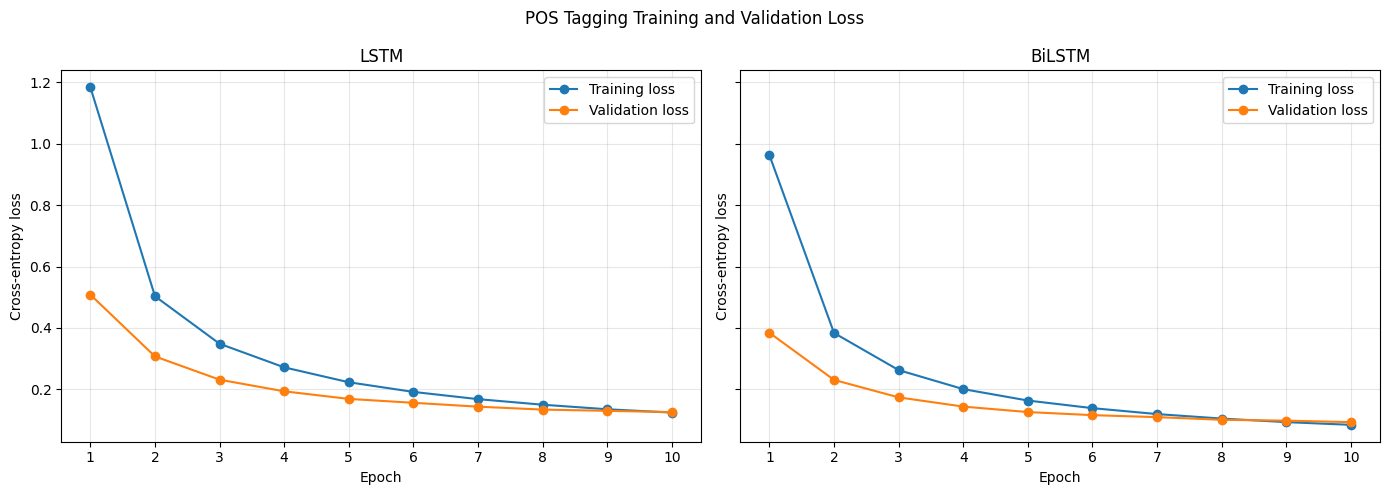

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for axis, model_name, history in [
    (axes[0], "LSTM", lstm_history),
    (axes[1], "BiLSTM", bilstm_history),
]:
    epochs = range(1, len(history["train_loss"]) + 1)
    axis.plot(epochs, history["train_loss"], marker="o", label="Training loss")
    axis.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    axis.set_title(model_name)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Cross-entropy loss")
    axis.set_xticks(list(epochs))
    axis.grid(alpha=0.3)
    axis.legend()

fig.suptitle("POS Tagging Training and Validation Loss")
plt.tight_layout()
plt.show()


## 20. Load Best Checkpoints and Evaluate

Evaluation uses only non-padding tokens. Each model receives the exact same test loader and label ordering.


In [22]:
def load_best_model(checkpoint_path: Path) -> LSTMPOSTagger:
    # The checkpoint was created locally by this notebook. Explicitly disabling
    # weights_only supports the metadata dictionaries on PyTorch 2.6+; the
    # fallback keeps compatibility with older Colab PyTorch versions.
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    model = LSTMPOSTagger(**checkpoint["model_config"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


best_lstm = load_best_model(lstm_checkpoint_path)
best_bilstm = load_best_model(bilstm_checkpoint_path)
_, _, test_loader = create_dataloaders(SEED)

evaluation_results = {}
for model_name, model in [("LSTM", best_lstm), ("BiLSTM", best_bilstm)]:
    test_loss, metrics, y_true, y_pred = run_epoch(
        model, test_loader, criterion, device
    )
    evaluation_results[model_name] = {
        "test_loss": test_loss,
        **metrics,
        "y_true": y_true,
        "y_pred": y_pred,
    }

comparison_df = pd.DataFrame(
    {
        model_name: {
            key: value
            for key, value in result.items()
            if key not in {"y_true", "y_pred"}
        }
        for model_name, result in evaluation_results.items()
    }
).T
display(comparison_df.style.format("{:.4f}"))


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

,test_loss,token_accuracy,macro_precision,macro_recall,macro_f1
LSTM,0.1255,0.9633,0.8923,0.8758,0.8804
BiLSTM,0.0920,0.9731,0.9403,0.9190,0.9244


## 21. Per-Tag Classification Reports

`<PAD>` is excluded explicitly. The report includes precision, recall, and F1 for every real POS tag.


In [23]:
real_pos_ids = list(range(1, NUM_POS_CLASSES))
real_pos_names = [id_to_pos[pos_id] for pos_id in real_pos_ids]

for model_name, result in evaluation_results.items():
    print("\n" + "=" * 100)
    print(f"{model_name} classification report")
    print("=" * 100)
    print(
        classification_report(
            result["y_true"],
            result["y_pred"],
            labels=real_pos_ids,
            target_names=real_pos_names,
            digits=4,
            zero_division=0,
        )
    )



LSTM classification report
              precision    recall  f1-score   support

           $     1.0000    1.0000    1.0000       159
           ,     1.0000    1.0000    1.0000      4832
           .     1.0000    1.0000    1.0000      7171
           :     0.6726    0.6032    0.6360       126
           ;     0.9706    1.0000    0.9851        33
          CC     1.0000    0.9971    0.9986      3459
          CD     0.9895    0.9325    0.9601      3746
          DT     0.9988    0.9982    0.9985     14764
          EX     0.9570    0.8990    0.9271        99
          FW     0.0000    0.0000    0.0000         0
          IN     0.9885    0.9870    0.9877     18132
          JJ     0.9224    0.9013    0.9117     11652
         JJR     0.8874    0.9513    0.9183       431
         JJS     0.9742    0.9498    0.9619       478
         LRB     1.0000    0.9815    0.9907       108
          MD     0.9971    0.9971    0.9971      1020
          NN     0.9720    0.9460    0.9588     21919

## 22. Model Comparison

The table and chart compare Token Accuracy, Macro Precision, Macro Recall, and Macro-F1 under the same data split and similar hyperparameters.


,token_accuracy,macro_precision,macro_recall,macro_f1
LSTM,0.9633,0.8923,0.8758,0.8804
BiLSTM,0.9731,0.9403,0.9190,0.9244


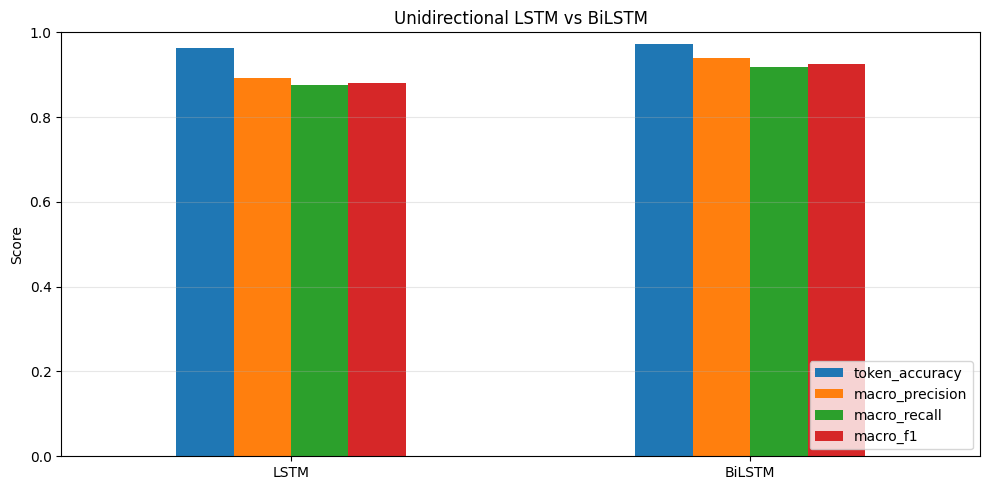

In [24]:
metric_columns = [
    "token_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
]
display(comparison_df[metric_columns].style.format("{:.4f}"))

comparison_df[metric_columns].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    rot=0,
)
plt.ylabel("Score")
plt.title("Unidirectional LSTM vs BiLSTM")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 23. Sentence-Level Prediction Helper

This helper returns one prediction per original token. Padding is removed using the sentence length before the output table is created.


In [25]:
@torch.no_grad()
def predict_dataset_sentence(
    model: nn.Module,
    frame: pd.DataFrame,
    sentence_index: int,
) -> pd.DataFrame:
    """Predict all token tags for one sentence from a split DataFrame."""
    tokens = frame.loc[sentence_index, "tokens"]
    true_tags = frame.loc[sentence_index, "pos_tags"]
    word_ids = [word_to_id.get(token, WORD_UNK_ID) for token in tokens]

    word_tensor = torch.tensor([word_ids], dtype=torch.long, device=device)
    length_tensor = torch.tensor([len(word_ids)], dtype=torch.long, device=device)
    logits = model(word_tensor, length_tensor)
    predicted_ids = logits.argmax(dim=-1).squeeze(0).cpu().tolist()[: len(tokens)]
    predicted_tags = [id_to_pos[pos_id] for pos_id in predicted_ids]

    assert len(tokens) == len(true_tags) == len(predicted_tags)
    return pd.DataFrame(
        {
            "token": tokens,
            "true_pos": true_tags,
            "predicted_pos": predicted_tags,
            "correct": [
                true_tag == predicted_tag
                for true_tag, predicted_tag in zip(true_tags, predicted_tags)
            ],
        }
    )


## 24. Display at Least 10 Sentence Predictions

Ten fixed test sentences are displayed for each model. Every table contains the token, true POS tag, predicted POS tag, and a correctness indicator.


In [26]:
number_of_examples = min(10, len(test_df))
if number_of_examples < 10:
    print(f"Warning: the test split contains only {number_of_examples} sentences.")

example_indices = list(range(number_of_examples))
for model_name, model in [("LSTM", best_lstm), ("BiLSTM", best_bilstm)]:
    print("\n" + "#" * 110)
    print(f"{model_name}: TOKEN-LEVEL PREDICTIONS FOR {number_of_examples} TEST SENTENCES")
    print("#" * 110)

    for display_number, sentence_index in enumerate(example_indices, start=1):
        sentence_id = test_df.loc[sentence_index, "sentence_id"]
        print(f"\n{model_name} | Sentence {display_number} | ID: {sentence_id}")
        prediction_table = predict_dataset_sentence(model, test_df, sentence_index)
        display(prediction_table)



##############################################################################################################
LSTM: TOKEN-LEVEL PREDICTIONS FOR 10 TEST SENTENCES
##############################################################################################################

LSTM | Sentence 1 | ID: Sentence: 22048


,token,true_pos,predicted_pos,correct
0,The,DT,DT,True
1,report,NN,NN,True
2,calls,VBZ,VBZ,True
3,on,IN,IN,True
4,President,NNP,NNP,True
5,Bush,NNP,NNP,True
6,and,CC,CC,True
7,Congress,NNP,NNP,True
8,to,TO,TO,True
9,urge,VB,VB,True



LSTM | Sentence 2 | ID: Sentence: 1273


,token,true_pos,predicted_pos,correct
0,The,DT,DT,True
1,construction,NN,NN,True
2,on,IN,IN,True
3,the,DT,DT,True
4,Baku-T'bilisi-Ceyhan,JJ,NNP,False
5,oil,NN,NN,True
6,pipeline,NN,NN,True
7,",",",",",",True
8,the,DT,DT,True
9,Baku-T'bilisi-Erzerum,JJ,NNP,False



LSTM | Sentence 3 | ID: Sentence: 1541


...

,token,true_pos,predicted_pos,correct
0,The,DT,DT,True
1,report,NN,NN,True
2,shows,VBZ,VBZ,True
3,that,IN,IN,True
4,murders,NNS,NNS,True
5,in,IN,IN,True
6,large,JJ,JJ,True
7,cities,NNS,NNS,True
8,",",",",",",True
9,with,IN,IN,True



BiLSTM | Sentence 9 | ID: Sentence: 8273


,token,true_pos,predicted_pos,correct
0,It,PRP,PRP,True
1,exploded,VBD,VBD,True
2,as,IN,IN,True
3,passengers,NNS,NNS,True
4,were,VBD,VBD,True
5,working,VBG,VBG,True
6,to,TO,TO,True
7,dismantle,VB,VB,True
8,the,DT,DT,True
9,roadblock,NN,NN,True



BiLSTM | Sentence 10 | ID: Sentence: 19145


,token,true_pos,predicted_pos,correct
0,In,IN,IN,True
1,the,DT,DT,True
2,past,JJ,JJ,True
3,few,JJ,JJ,True
4,years,NNS,NNS,True
5,",",",",",",True
6,Uighur,NNP,NNP,True
7,separatist,NN,NN,True
8,groups,NNS,NNS,True
9,have,VBP,VBP,True


## 25. Inference for a New Tokenized Sentence

The model was trained on the dataset's original tokenization. For reliable inference, pass a list of pre-tokenized words or punctuation symbols. The function returns one POS prediction for every supplied token.


In [27]:
@torch.no_grad()
def predict_pos_tags(tokens: list[str], model=best_bilstm) -> pd.DataFrame:
    """Predict one POS tag for every token in a new sentence."""
    if not tokens:
        raise ValueError("Provide at least one token.")

    normalized_tokens = [
        unicodedata.normalize("NFC", str(token)).strip()
        for token in tokens
    ]
    if any(token == "" for token in normalized_tokens):
        raise ValueError("Tokens must not be empty.")

    word_ids = [word_to_id.get(token, WORD_UNK_ID) for token in normalized_tokens]
    word_tensor = torch.tensor([word_ids], dtype=torch.long, device=device)
    length_tensor = torch.tensor([len(word_ids)], dtype=torch.long, device=device)
    logits = model(word_tensor, length_tensor)
    probabilities = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    predicted_ids = probabilities.argmax(axis=1)

    return pd.DataFrame(
        {
            "token": normalized_tokens,
            "predicted_pos": [id_to_pos[int(pos_id)] for pos_id in predicted_ids],
            "confidence": [
                float(probabilities[index, pos_id])
                for index, pos_id in enumerate(predicted_ids)
            ],
        }
    )


example_tokens = ["The", "food", "was", "delicious", "."]
display(predict_pos_tags(example_tokens, model=best_bilstm))


,token,predicted_pos,confidence
0,The,DT,1.000000
1,food,NN,0.999990
2,was,VBD,0.999919
3,delicious,NNP,0.711761
4,.,.,0.999999


## 26. Visualize Real Token-Level Predictions

The following heatmap shows actual BiLSTM predictions from held-out test sentences.
Each cell contains the token and the `true → predicted` POS transition. Green cells
are correct; red cells are errors; gray cells are padding added only for plotting.
The bar chart summarizes per-sentence token accuracy for the same examples.

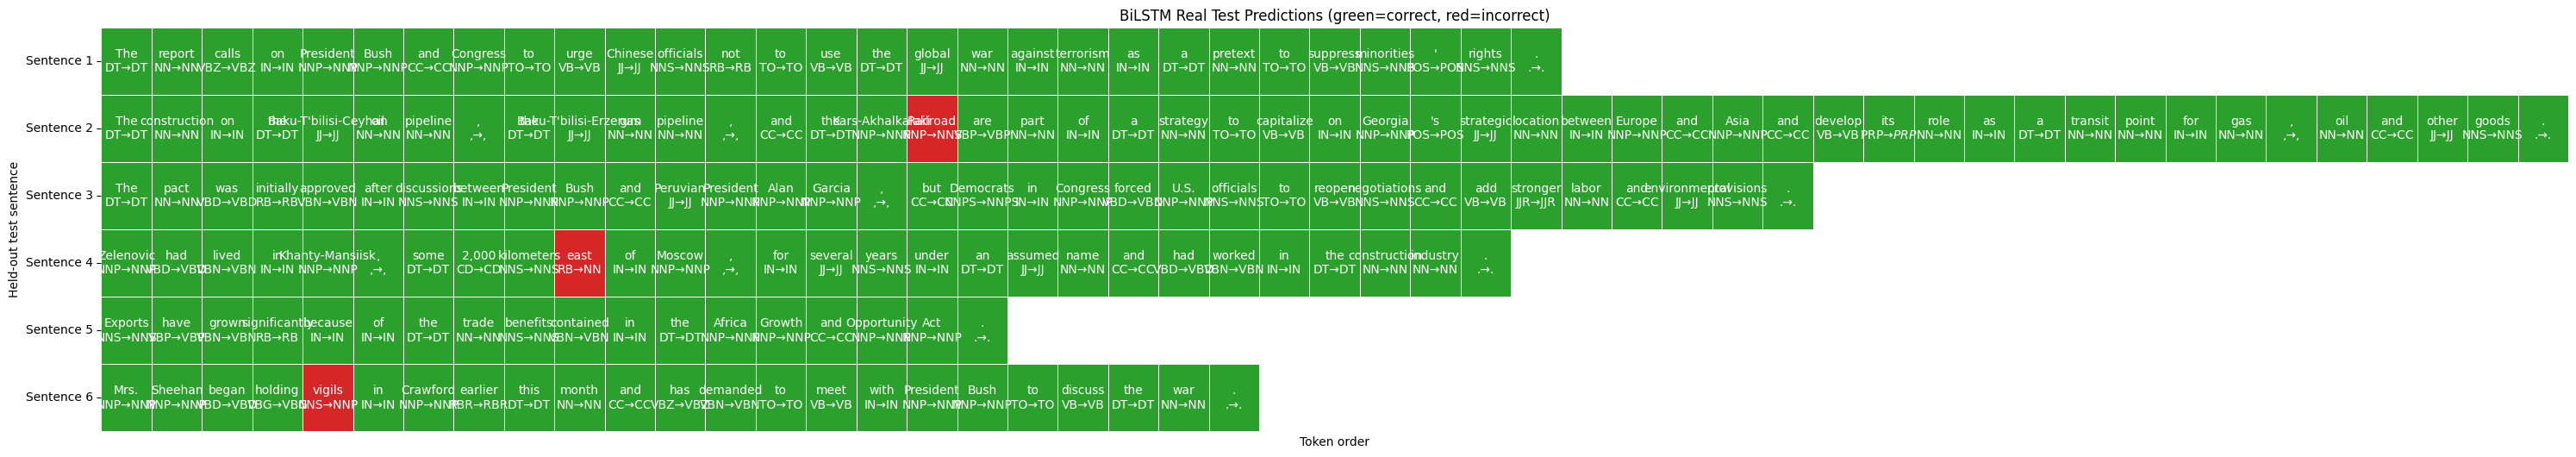

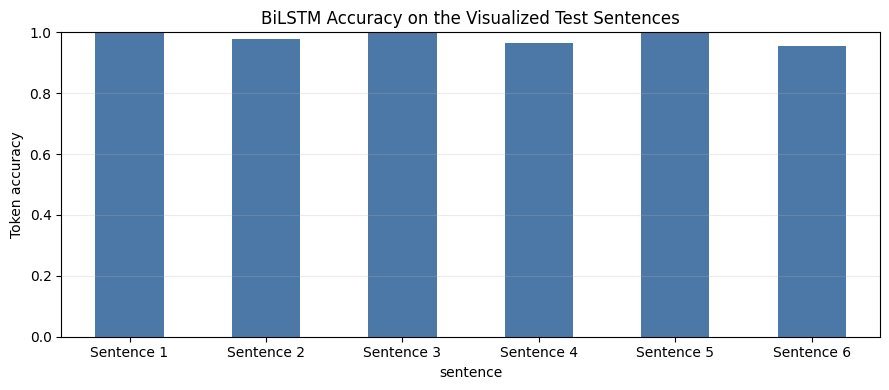

,sentence,token_accuracy,token_count
0,Sentence 1,1.0000,29
1,Sentence 2,0.9796,49
2,Sentence 3,1.0000,34
3,Sentence 4,0.9643,28
4,Sentence 5,1.0000,18
5,Sentence 6,0.9565,23


In [28]:
visualized_sentence_count = min(6, len(test_df))
visualized_indices = list(range(visualized_sentence_count))
prediction_tables = [
    predict_dataset_sentence(best_bilstm, test_df, index)
    for index in visualized_indices
]

max_visualized_length = max(len(table) for table in prediction_tables)
correctness_matrix = np.full(
    (visualized_sentence_count, max_visualized_length),
    np.nan,
)
annotation_matrix = np.full(
    (visualized_sentence_count, max_visualized_length),
    "",
    dtype=object,
)
sentence_accuracies = []

for row_index, table in enumerate(prediction_tables):
    length = len(table)
    correctness = table["correct"].astype(float).to_numpy()
    correctness_matrix[row_index, :length] = correctness
    sentence_accuracies.append(correctness.mean())
    for token_index, row in table.iterrows():
        annotation_matrix[row_index, token_index] = (
            f"{row['token']}\n{row['true_pos']}→{row['predicted_pos']}"
        )

figure_width = max(14, min(30, 0.9 * max_visualized_length))
fig, axis = plt.subplots(
    figsize=(figure_width, max(4, 0.9 * visualized_sentence_count))
)
sns.heatmap(
    correctness_matrix,
    mask=np.isnan(correctness_matrix),
    annot=annotation_matrix,
    fmt="",
    cmap=sns.color_palette(["#d62728", "#2ca02c"], as_cmap=True),
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    yticklabels=[
        f"Sentence {index + 1}"
        for index in visualized_indices
    ],
    xticklabels=False,
    ax=axis,
)
axis.set_title("BiLSTM Real Test Predictions (green=correct, red=incorrect)")
axis.set_ylabel("Held-out test sentence")
axis.set_xlabel("Token order")
plt.tight_layout()
plt.show()

accuracy_frame = pd.DataFrame(
    {
        "sentence": [f"Sentence {index + 1}" for index in visualized_indices],
        "token_accuracy": sentence_accuracies,
        "token_count": [len(table) for table in prediction_tables],
    }
)
axis = accuracy_frame.plot(
    x="sentence",
    y="token_accuracy",
    kind="bar",
    color="#4c78a8",
    legend=False,
    figsize=(9, 4),
    ylim=(0, 1),
    rot=0,
)
axis.set_ylabel("Token accuracy")
axis.set_title("BiLSTM Accuracy on the Visualized Test Sentences")
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
display(accuracy_frame.style.format({"token_accuracy": "{:.4f}"}))

## 27. Summary

This notebook completed a leakage-safe sequence-tagging workflow:

- Anonymous public-dataset download with `kagglehub` and automatic schema inspection.
- Automatic sentence ID, token, and POS detection with NER labels excluded.
- Forward-filled sentence identifiers and complete sentence-level grouping.
- Sentence-level train/validation/test splitting.
- Training-only word vocabulary and a stable corpus-level POS output schema.
- Simultaneous dynamic padding and packed recurrent computation.
- One POS prediction per token using LSTM and BiLSTM models.
- Padding-aware loss and metrics, early stopping, checkpointing, and per-tag reports.
- Fair model comparison and readable sentence-level prediction tables.


## 28. Extended Practice and Alternative Datasets

For quick experiments, set `SAMPLE_LIMIT` to the number of complete sentences.
Never sample individual token rows because doing so breaks sentence boundaries and
token–tag alignment.

### Core exercises

1. **LSTM versus BiLSTM.** Repeat training with three seeds and report mean and
   standard deviation for token accuracy and macro-F1. Compare training time and
   parameter count.
2. **Rare-tag analysis.** Find POS tags with fewer than 100 training examples.
   Visualize their precision, recall, F1, and most frequent confusion partner.
3. **Unknown-word analysis.** Divide test tokens into known and `<UNK>` groups.
   Calculate token accuracy for each group and display ten unknown-word errors.
4. **Sentence-length analysis.** Bucket test sentences by length and plot accuracy
   for each bucket. Determine whether long sequences create more errors.
5. **Padding efficiency.** Compare random batching with length-bucketed batching.
   Measure padding ratio, epoch time, and macro-F1.
6. **Context ablation.** Replace the recurrent model with a token-only embedding
   classifier. The performance difference estimates the value of sentence context.

### Practice with other datasets

- [Universal Dependencies Vietnamese VTB](https://universaldependencies.org/treebanks/vi_vtb/index.html):
  convert CoNLL-U `FORM` and `UPOS` fields into token/POS sequences and evaluate
  Vietnamese POS tagging.
- [Universal Dependencies English EWT](https://universaldependencies.org/treebanks/en_ewt/index.html):
  repeat the experiment in English and compare tag frequency and unknown-word errors.
- [Universal Dependencies dataset on Hugging Face](https://huggingface.co/datasets/universal-dependencies/universal_dependencies):
  select two languages, keep the shared UPOS inventory, and compare monolingual with
  multilingual training.
- [CoNLL-2003](https://huggingface.co/datasets/eriktks/conll2003):
  adapt the same sequence model from POS tagging to NER by changing the target field
  while retaining padding-aware loss and evaluation.

### Challenge exercises

1. Add a character-level BiLSTM representation to improve predictions for unknown
   words and spelling variants.
2. Add a CRF decoding layer and verify that it improves sequence consistency.
3. Jointly predict POS and NER with a shared BiLSTM encoder and two output heads.
4. Train on English EWT and evaluate zero-shot on another language using aligned or
   multilingual word embeddings.
5. Create an interactive error viewer that filters by POS tag, sentence length,
   known/unknown word status, and model confidence.